# Analysis of Neuronal Exon Inclusion Changes Over Time

In [1]:
!pip install ipykernel
!python -m ipykernel install --user --name finalproject --display-name "Python (final project)"

Installed kernelspec finalproject in /home/biouser/.local/share/jupyter/kernels/finalproject


In [2]:
## 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from exon_inclusion_functions import (
    load_type_data,
    compute_spearman_corr,
    spearman_corr_labels,
    preprocess_type,
    load_subtype_data,
    preprocess_subtype,
    compute_spearman_ci,
)

In [3]:
## Define colour palettes

# Ages 
ages = ["P14", "P21", "P28", "P56"]
ages_colour = ["#ae3b24", "#c8812a", "#56632c" ,"#f68d62"]
ages_palette = dict(zip(ages, ages_colour))

# Regions
regions = ["VIS", "HIPP"]
regions_colour = ["#ddbbc6", "#fdc681"]
regions_palette = dict(zip(regions, regions_colour))

# Cell types
cts = ["Excite", "Inhib"]
cts_colour = ["#ffcc5c", "#65c3ba"]
cts_palette = dict(zip(cts, cts_colour))

## 1. Load Data
- Load `altExonUsage_devel_type.gz`
- Filter only column with `Neuron` 
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)
- Remove rows with missing data `NaN`

In [4]:
type_neurons = load_type_data("../../data/altExonUsage_devel_type.gz")
type_neurons.head(10)

,P14_Hippocampus_ExciteNeuron,P14_Hippocampus_InhibNeuron,P14_VisCortex_ExciteNeuron,P14_VisCortex_InhibNeuron,P21_Hippocampus_ExciteNeuron,P21_Hippocampus_InhibNeuron,P21_VisCortex_ExciteNeuron,P21_VisCortex_InhibNeuron,P28_Hippocampus_ExciteNeuron,P28_Hippocampus_InhibNeuron,P28_VisCortex_ExciteNeuron,P28_VisCortex_InhibNeuron,P56_Hippocampus_ExciteNeuron,P56_Hippocampus_InhibNeuron,P56_VisCortex_ExciteNeuron,P56_VisCortex_InhibNeuron
GE,,,,,,,,,,,,,,,,
chr1_162273620_162273649_-::ENSMUSG00000040265.16,0.032520,0.000000,0.008152,0.000000,0.049351,0.024000,0.000000,0.000000,0.015544,0.007812,0.001163,0.000000,0.015831,0.026316,0.005181,0.001821
chr1_83384894_83384972_-::ENSMUSG00000026163.17,0.608364,0.642140,0.707604,0.657718,0.631307,0.707113,0.767779,0.776471,0.670919,0.666667,0.789824,0.805970,0.641826,0.694915,0.781662,0.712150
chr1_16486020_16486150_-::ENSMUSG00000025920.19,0.204724,0.032967,0.240229,0.097222,0.222116,0.230769,0.275465,0.102564,0.223958,0.000000,0.230177,0.132075,0.218418,0.050633,0.220895,0.145867
chr1_30837105_30837266_-::ENSMUSG00000048874.15,0.159420,0.082569,0.141469,0.195122,0.148862,0.163043,0.153000,0.217391,0.192575,0.172414,0.170354,0.205882,0.128942,0.253333,0.183346,0.246057
chr1_42663556_42663602_-::ENSMUSG00000060424.14,0.313793,0.322222,0.341404,0.342593,0.353125,0.354167,0.423520,0.370968,0.304668,0.275862,0.426385,0.526316,0.388466,0.400000,0.439563,0.340741
chr1_84795690_84795815_-::ENSMUSG00000026219.14,0.288591,0.472222,0.331536,0.444444,0.320594,0.327273,0.362587,0.466667,0.322695,0.523810,0.380399,0.363636,0.278626,0.428571,0.391031,0.355769
chr1_121312201_121312325_-::ENSMUSG00000003721.14,0.891176,0.910448,0.803970,0.846154,0.797701,0.858974,0.817054,0.812500,0.903448,0.833333,0.898990,0.940000,0.806051,0.921569,0.849558,0.894118
chr1_121307140_121307306_-::ENSMUSG00000003721.14,0.896359,0.914286,0.814554,0.857143,0.800680,0.860759,0.824047,0.823529,0.906822,0.846154,0.902439,0.941176,0.812874,0.927273,0.850332,0.892000
chr1_133004654_133004721_-::ENSMUSG00000054387.13,0.994475,0.804348,0.975676,0.857143,0.845659,0.406977,0.786689,0.394737,0.938511,0.842105,0.965812,0.851852,0.964720,0.722222,0.947581,0.783784


## 2. Performn Pairwise Correlation

- Compute Spearman correlation matrix
- Rename indices "Hippocampus" -> "HIPP" & "VisCortex" -> "VIS" 

In [5]:
CN = compute_spearman_corr(type_neurons)
CN = preprocess_type(CN)
CN

,P14_HIPP_Excite,P14_HIPP_Inhib,P14_VIS_Excite,P14_VIS_Inhib,P21_HIPP_Excite,P21_HIPP_Inhib,P21_VIS_Excite,P21_VIS_Inhib,P28_HIPP_Excite,P28_HIPP_Inhib,P28_VIS_Excite,P28_VIS_Inhib,P56_HIPP_Excite,P56_HIPP_Inhib,P56_VIS_Excite,P56_VIS_Inhib
P14_HIPP_Excite,1.000000,0.884217,0.962237,0.899971,0.971003,0.868121,0.947010,0.860983,0.949210,0.850278,0.943170,0.880083,0.961826,0.902950,0.934050,0.886542
P14_HIPP_Inhib,0.884217,1.000000,0.878134,0.910373,0.870207,0.916648,0.853516,0.846149,0.863946,0.909185,0.855788,0.883274,0.869281,0.925440,0.854794,0.904063
P14_VIS_Excite,0.962237,0.878134,1.000000,0.925685,0.954540,0.876602,0.964306,0.877206,0.928853,0.850946,0.958362,0.900242,0.935769,0.900521,0.946463,0.906316
P14_VIS_Inhib,0.899971,0.910373,0.925685,1.000000,0.890136,0.889708,0.888126,0.880438,0.871564,0.882559,0.886951,0.917194,0.883123,0.912734,0.880189,0.913409
P21_HIPP_Excite,0.971003,0.870207,0.954540,0.890136,1.000000,0.886830,0.973686,0.887591,0.968928,0.860166,0.964302,0.892825,0.981593,0.917818,0.965583,0.909689
P21_HIPP_Inhib,0.868121,0.916648,0.876602,0.889708,0.886830,1.000000,0.892030,0.904615,0.879264,0.911842,0.881864,0.912125,0.874085,0.931539,0.885403,0.941667
P21_VIS_Excite,0.947010,0.853516,0.964306,0.888126,0.973686,0.892030,1.000000,0.912379,0.950948,0.858103,0.980269,0.900454,0.952490,0.905970,0.983004,0.925432
P21_VIS_Inhib,0.860983,0.846149,0.877206,0.880438,0.887591,0.904615,0.912379,1.000000,0.883744,0.859579,0.891405,0.899474,0.874334,0.891868,0.899297,0.925791
P28_HIPP_Excite,0.949210,0.863946,0.928853,0.871564,0.968928,0.879264,0.950948,0.883744,1.000000,0.874911,0.966287,0.884917,0.970060,0.912727,0.951848,0.906948
P28_HIPP_Inhib,0.850278,0.909185,0.850946,0.882559,0.860166,0.911842,0.858103,0.859579,0.874911,1.000000,0.863372,0.891848,0.856964,0.916498,0.858614,0.912753


## 3. Heat Map of Pairwise Correlation for Excitatory and Inhibitory Types

- Extract metadata from the table's index to create labels for the heat map
    - `Age`, `Region`, `Type` 
- Create colour palettes for each label
- Create a cluster map
    - Dendrogram of excitatory type & inhitory type
    - Heat map of Spearman pairwise correlations of exon inclusion for each cell type 

In [6]:
# Create labels for the heatmap
cnn = spearman_corr_labels(CN)
cnn

,CT,Age,Region,Type
0,P14_HIPP_Excite,P14,HIPP,Excite
1,P14_HIPP_Inhib,P14,HIPP,Inhib
2,P14_VIS_Excite,P14,VIS,Excite
3,P14_VIS_Inhib,P14,VIS,Inhib
4,P21_HIPP_Excite,P21,HIPP,Excite
5,P21_HIPP_Inhib,P21,HIPP,Inhib
6,P21_VIS_Excite,P21,VIS,Excite
7,P21_VIS_Inhib,P21,VIS,Inhib
8,P28_HIPP_Excite,P28,HIPP,Excite
9,P28_HIPP_Inhib,P28,HIPP,Inhib


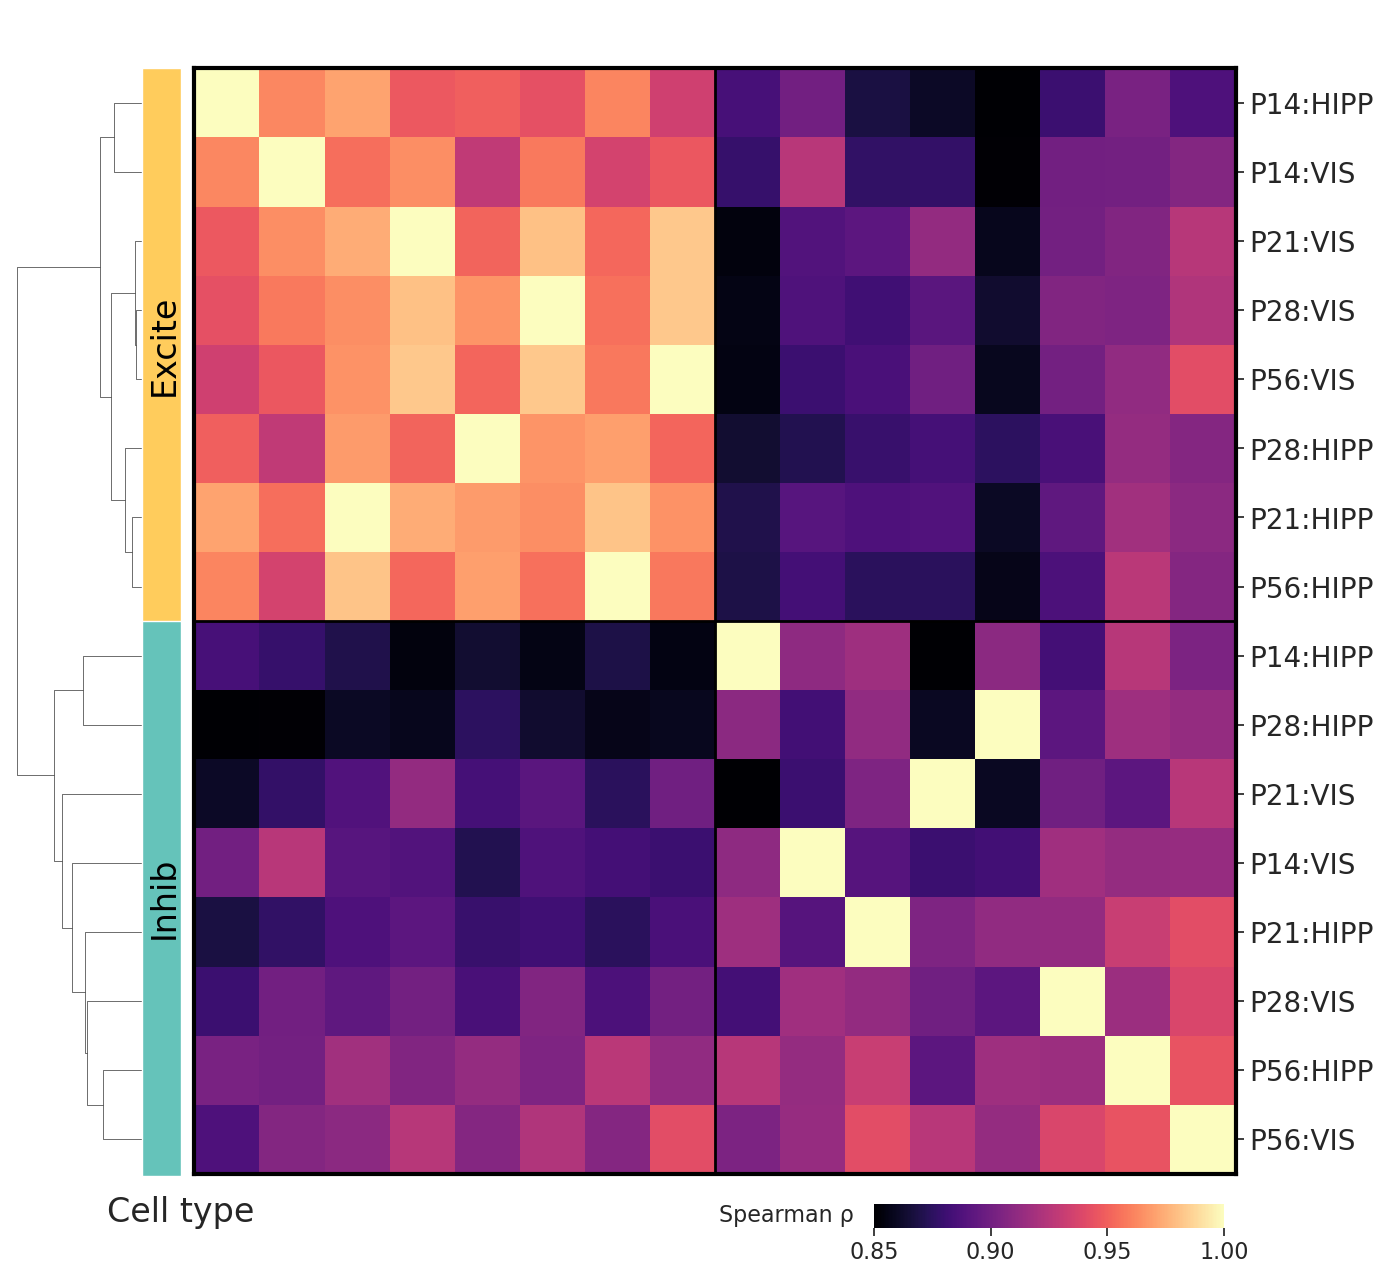

In [7]:
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from matplotlib.patches import Rectangle

# Prepare row order
excite = cnn[cnn["Type"] == "Excite"]["CT"].tolist()
inhib  = cnn[cnn["Type"] == "Inhib"]["CT"].tolist()

row_order = excite + inhib
CN2 = CN.loc[row_order, row_order]

np.fill_diagonal(CN2.values, 1.0)

# Create masked correlation 
CN_masked = CN2.copy()

# Set cross-type correlations LOW
for r in excite:
    for c in inhib:
        CN_masked.loc[r, c] = 0
        CN_masked.loc[c, r] = 0

# Force symmetry and diagonal 
CN_masked = (CN_masked + CN_masked.T) / 2
np.fill_diagonal(CN_masked.values, 1)

# Convert correlation → distance
dist = 1 - CN_masked

# Linkage 2 clusters
condensed = squareform(dist.values, checks=True)
Z = sch.linkage(condensed, method="complete", optimal_ordering=True)

# Side colour labels
row_colours = pd.Series(row_order).map(
    lambda ct: cts_palette["Excite"] if ct in excite else cts_palette["Inhib"]
)

# Clustermap 
sns.set_theme(style="white")

g = sns.clustermap(
    CN2,
    figsize=(14, 12),
    row_colors=row_colours,
    col_cluster=False,
    cmap="magma",
    vmin=0.85,
    vmax=1.0,
    dendrogram_ratio=(0.12, 0.05),
    cbar_kws= {"orientation": "horizontal", "ticks" : [0.85, 0.9, 0.95, 1.0]},
    cbar_pos=(0.63, -0.03, 0.25, 0.02),
    xticklabels=False,
    yticklabels=True,
)

# Rename y-tick labels -> Age:Region
ylabels = []
for ct in g.data2d.index:
    row = cnn.loc[cnn["CT"] == ct].iloc[0]
    label = f"{row['Age']}:{row['Region']}"
    ylabels.append(label)

g.ax_heatmap.set_yticklabels(ylabels, fontsize=20)

# Add border
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(3)
    spine.set_color("black")

# Add cluster border line
n_excite = len(excite)
g.ax_heatmap.axhline(n_excite, color="black", linewidth=2)
g.ax_heatmap.axvline(n_excite, color="black", linewidth=2)

# Add cluster labels
ax = g.ax_heatmap

# Excite
ax.text(-0.47, n_excite/2, "Excite",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Inhib
ax.text(-0.47, n_excite + (len(inhib)/2), "Inhib",
        rotation=90,
        va="center",
        ha="center",
        fontsize=24,
        color="black",
)

# Add rectangular colour blocks for cluster labels
ax.add_patch(Rectangle(
    (-0.8, 0),
    0.6,
    n_excite + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Excite"],
    clip_on=False
))

ax.add_patch(Rectangle(
    (-0.8, n_excite),
    0.6,
    len(inhib) + 0.03,
    transform=ax.transData,
    facecolor=cts_palette["Inhib"],
    clip_on=False
))

g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.text(
    -1.35, 16.8,
    "Cell type",
    va="bottom",
    ha="left",
    fontsize=24,
)

# Add colour bar
cbar = g.cax
cbar.set_ylabel(None)
cbar.text(
    -0.25, 0.03,               
    "Spearman ρ",             
    va="bottom",
    ha="center",
    fontsize=16,
    transform=cbar.transAxes,
)

# Increase tick label font size
for tick in cbar.get_xticklabels():
    tick.set_fontsize(16)

plt.savefig("../plots/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Box Plot of Pairwise Correlation for Excitatory and Inhibitory Types

- Load `altExonUsage_devel_subtype.gz`
- Filter only column with `Inh`, `Excite`, `Granule`, and `NIPC`
- Combine `Exon` and `Gene` to `GE` (`Exon::Gene`)
- Remove rows and columns where >95% of values are missing
- Compute Spearman correlation matrix
- Separate neuronal cell types into 3 types: `Excite`, `Inh`, and `Inhib` 
    - Get the upper triangle matrix for `Excite` (Excite), `Inh` / `Inh_wCR` (Inhib with CajalRetz), and `Inhib` (Inhib without CajalRetz).

In [8]:
subtype_alt = load_subtype_data("../../data/altExonUsage_devel_subtype.gz")
subtype_alt.shape

(192, 50)

In [9]:
subtype_alt.head(10)

,P14_Hippocampus_ExciteCA,P14_Hippocampus_ExciteDG,P14_Hippocampus_InhCajalRetzius,P14_Hippocampus_InhibNeuron,P14_Hippocampus_GranuleNB,P14_Hippocampus_NIPCs,P14_VisCortex_ExciteL23,P14_VisCortex_ExciteL4,P14_VisCortex_ExciteL5,P14_VisCortex_ExciteL6,...,P56_Hippocampus_InhibNeuron,P56_Hippocampus_GranuleNB,P56_Hippocampus_NIPCs,P56_VisCortex_ExciteL23,P56_VisCortex_ExciteL4,P56_VisCortex_ExciteL5,P56_VisCortex_ExciteL6,P56_VisCortex_ExciteNP,P56_VisCortex_InhibNeuron,P56_VisCortex_NIPCs
GE,,,,,,,,,,,,,,,,,,,,,
chr1_156892908_156893012_-::ENSMUSG00000026594.14,0.179245,0.176044,0.199005,0.258621,0.194853,0.106509,0.266129,0.216783,0.274657,0.221698,...,0.220339,0.168142,0.136364,0.207547,0.267000,0.267399,0.242922,0.235669,0.283654,0.078947
chr1_161037124_161037164_+::ENSMUSG00000053332.13,0.063953,0.066667,0.208145,0.125000,0.032661,0.278523,0.039216,0.031915,0.055215,0.064286,...,0.069767,0.027431,0.317073,0.033473,0.020251,0.016548,0.031705,0.074866,0.053333,0.212389
chr1_128162769_128162858_+::ENSMUSG00000056211.13,0.979253,0.923358,0.971429,0.869565,0.395176,0.117409,0.983713,0.982086,0.969697,0.988095,...,0.931507,0.473214,0.060000,0.995899,0.982956,0.985051,0.983323,0.966543,0.976546,0.272059
chr1_161036549_161036579_+::ENSMUSG00000053332.13,0.976923,0.984962,0.981651,1.000000,0.979021,0.872727,0.973684,0.987013,0.972028,0.984127,...,0.991935,0.984456,0.923077,0.974057,0.985771,0.989418,0.982961,0.988166,0.991803,0.947619
chr1_161037288_161037315_+::ENSMUSG00000053332.13,0.875776,0.893750,0.896396,0.933333,0.829338,0.795302,0.857143,0.881720,0.838509,0.838235,...,0.848000,0.872500,0.886179,0.865639,0.833692,0.843137,0.839323,0.837838,0.858434,0.864035
chr1_37892943_37893023_+::ENSMUSG00000026087.11,0.750693,0.759524,0.449541,0.641509,0.716484,0.767470,0.793388,0.781437,0.785156,0.785095,...,0.554113,0.690722,0.739535,0.759969,0.737688,0.745882,0.730351,0.720930,0.594072,0.720461
chr1_161036208_161036244_+::ENSMUSG00000053332.13,0.984496,0.984733,0.962791,0.923077,0.978745,0.915751,0.972973,0.974359,0.965517,0.976190,...,0.983333,0.973753,0.923729,0.982968,0.982244,0.983784,0.987966,0.964286,0.993377,0.903846
chr1_5093363_5093452_+::ENSMUSG00000033793.12,0.990291,1.000000,0.983333,1.000000,0.994220,0.988636,1.000000,1.000000,0.995238,0.985401,...,0.984615,1.000000,1.000000,0.985772,0.984778,0.987654,0.989561,0.981481,0.976471,0.916667
chr1_180093944_180094186_+::ENSMUSG00000026490.18,0.982833,0.986486,0.969231,0.944444,0.830946,0.797101,0.970588,0.972477,0.984848,0.985000,...,0.974359,1.000000,0.833333,0.986607,0.976096,0.939698,0.982949,0.978723,0.945545,0.636364


In [10]:
CN_subtype = compute_spearman_corr(subtype_alt)
CN_subtype

,P14_Hippocampus_ExciteCA,P14_Hippocampus_ExciteDG,P14_Hippocampus_InhCajalRetzius,P14_Hippocampus_InhibNeuron,P14_Hippocampus_GranuleNB,P14_Hippocampus_NIPCs,P14_VisCortex_ExciteL23,P14_VisCortex_ExciteL4,P14_VisCortex_ExciteL5,P14_VisCortex_ExciteL6,...,P56_Hippocampus_InhibNeuron,P56_Hippocampus_GranuleNB,P56_Hippocampus_NIPCs,P56_VisCortex_ExciteL23,P56_VisCortex_ExciteL4,P56_VisCortex_ExciteL5,P56_VisCortex_ExciteL6,P56_VisCortex_ExciteNP,P56_VisCortex_InhibNeuron,P56_VisCortex_NIPCs
P14_Hippocampus_ExciteCA,1.000000,0.955454,0.866749,0.936995,0.839317,0.617562,0.966144,0.971221,0.968467,0.968943,...,0.934740,0.849289,0.560518,0.950096,0.952416,0.954851,0.957910,0.933291,0.932536,0.688795
P14_Hippocampus_ExciteDG,0.955454,1.000000,0.876057,0.918360,0.869545,0.625415,0.952224,0.953295,0.954407,0.954382,...,0.924517,0.865592,0.562834,0.930599,0.928113,0.921015,0.926679,0.909433,0.900238,0.674056
P14_Hippocampus_InhCajalRetzius,0.866749,0.876057,1.000000,0.879243,0.859538,0.680193,0.854569,0.853535,0.849957,0.860612,...,0.905896,0.869565,0.642880,0.846593,0.851858,0.859103,0.859070,0.867456,0.904269,0.712721
P14_Hippocampus_InhibNeuron,0.936995,0.918360,0.879243,1.000000,0.868319,0.644217,0.936221,0.931209,0.933035,0.938562,...,0.922225,0.871150,0.585930,0.892168,0.907057,0.917177,0.914054,0.907699,0.928573,0.697314
P14_Hippocampus_GranuleNB,0.839317,0.869545,0.859538,0.868319,1.000000,0.826004,0.838973,0.826155,0.836080,0.839082,...,0.822265,0.968956,0.765269,0.774449,0.781975,0.793605,0.792794,0.778660,0.817130,0.852189
P14_Hippocampus_NIPCs,0.617562,0.625415,0.680193,0.644217,0.826004,1.000000,0.595853,0.565256,0.571884,0.578900,...,0.571851,0.796211,0.958961,0.518744,0.517511,0.532931,0.543370,0.517494,0.568909,0.938861
P14_VisCortex_ExciteL23,0.966144,0.952224,0.854569,0.936221,0.838973,0.595853,1.000000,0.973762,0.971712,0.975033,...,0.926151,0.836430,0.521197,0.931217,0.941154,0.941237,0.939431,0.916569,0.913778,0.656938
P14_VisCortex_ExciteL4,0.971221,0.953295,0.853535,0.931209,0.826155,0.565256,0.973762,1.000000,0.982268,0.980191,...,0.920369,0.830866,0.496038,0.941114,0.948794,0.950036,0.948935,0.927570,0.919467,0.627494
P14_VisCortex_ExciteL5,0.968467,0.954407,0.849957,0.933035,0.836080,0.571884,0.971712,0.982268,1.000000,0.988755,...,0.924317,0.829910,0.496384,0.951966,0.959765,0.959667,0.959918,0.932622,0.921415,0.649953
P14_VisCortex_ExciteL6,0.968943,0.954382,0.860612,0.938562,0.839082,0.578900,0.975033,0.980191,0.988755,1.000000,...,0.922195,0.831978,0.501082,0.945030,0.953987,0.957091,0.956426,0.935639,0.923492,0.653076


In [27]:
df_4b = preprocess_subtype(CN_subtype)

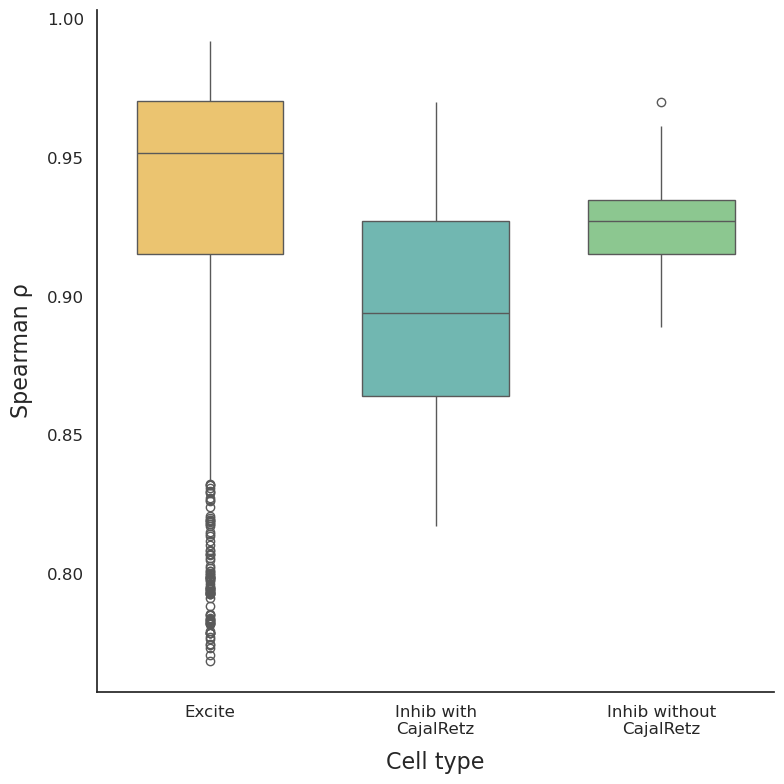

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cts_pal2 = {'Excite': '#ffcc5c', 'Inhib with\nCajalRetz': '#65c3ba', 'Inhib without\nCajalRetz': '#82d188'}

bplot_label = {
    "Excite": "Excite",
    "Inh_wCR": "Inhib with\nCajalRetz",
    "Inhib": "Inhib without\nCajalRetz"
}

bplot = df_4b.copy()
bplot["Type"] = bplot["Type"].map(bplot_label)

plt.figure(figsize=(8,8))

sns.boxplot(
    data=bplot, 
    x="Type", 
    y="CorValue", 
    hue="Type",
    whis=1.5,
    showcaps=False,
    palette=cts_pal2,
    width=0.65,
)

sns.despine()

plt.xlabel("Cell type", fontsize=16,labelpad=10)
plt.ylabel("Spearman ρ", fontsize=16, labelpad=10)

plt.yticks([0.80, 0.85, 0.90, 0.95, 1.00], fontsize=12)
plt.xticks(fontsize=12)

plt.tight_layout()

plt.savefig("../plots/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Compute Transition Correlations of Exon Inclusion for Each Cell Type in Each Brain Region

- Order the correlations by pairs of timepoints 
- Compute the lower bound and upper bound of the error bars indicating 95% confidence intervals for Spearmans's correlation for both neuronal cell types
- Create a dataframe containing correlation values, lower bound and upper bound of 95% confidence intervals, brain region, cell type, and time point in development process for each transition in each brain region 
- Create bar charts showing the changes in correlation values between different development timepoints for each brain region. The error bar indicating the upper and lower bound of the data points 

In [13]:
timepoints = ["P14", "P21", "P28", "P56"]
regions = ["Hippocampus", "VisCortex"]

# pairs of timepoints
combs = np.array([
    timepoints[0:3],  
    timepoints[1:4]   
])

In [14]:
cor_neurons_ci = []

for region in regions:
    for c in range(combs.shape[1]):  # 3 transitions
        tps = combs[:, c]  # start -> end
        for ct in cts:
            # columns containing start timepoint, region, and cell type
            col1 = [col for col in type_neurons.columns if tps[0] in col and region in col and ct in col]
            col2 = [col for col in type_neurons.columns if tps[1] in col and region in col and ct in col]
            if len(col1) == 0 or len(col2) == 0:
                continue
            v1 = type_neurons[col1].mean(axis=1)
            v2 = type_neurons[col2].mean(axis=1)
            r, lci, uci = compute_spearman_ci(v1, v2)
            cor_neurons_ci.append({
                "Estimate": r,
                "LCI": lci,
                "UCI": uci,
                "Region": region,
                "Cell type": ct,
                "Transition": f"{tps[0]} → {tps[1]}"
            })

cor_neurons_df = pd.DataFrame(cor_neurons_ci)
cor_neurons_df

,Estimate,LCI,UCI,Region,Cell type,Transition
0,0.971003,0.965060,0.975948,Hippocampus,Excite,P14 → P21
1,0.916648,0.900128,0.930536,Hippocampus,Inhib,P14 → P21
2,0.968928,0.962567,0.974222,Hippocampus,Excite,P21 → P28
3,0.911842,0.894421,0.926499,Hippocampus,Inhib,P21 → P28
4,0.970060,0.963926,0.975163,Hippocampus,Excite,P28 → P56
5,0.916498,0.899949,0.930409,Hippocampus,Inhib,P28 → P56
6,0.964306,0.957020,0.970376,VisCortex,Excite,P14 → P21
7,0.880438,0.857275,0.900044,VisCortex,Inhib,P14 → P21
8,0.980269,0.976202,0.983647,VisCortex,Excite,P21 → P28
9,0.899474,0.879763,0.916098,VisCortex,Inhib,P21 → P28


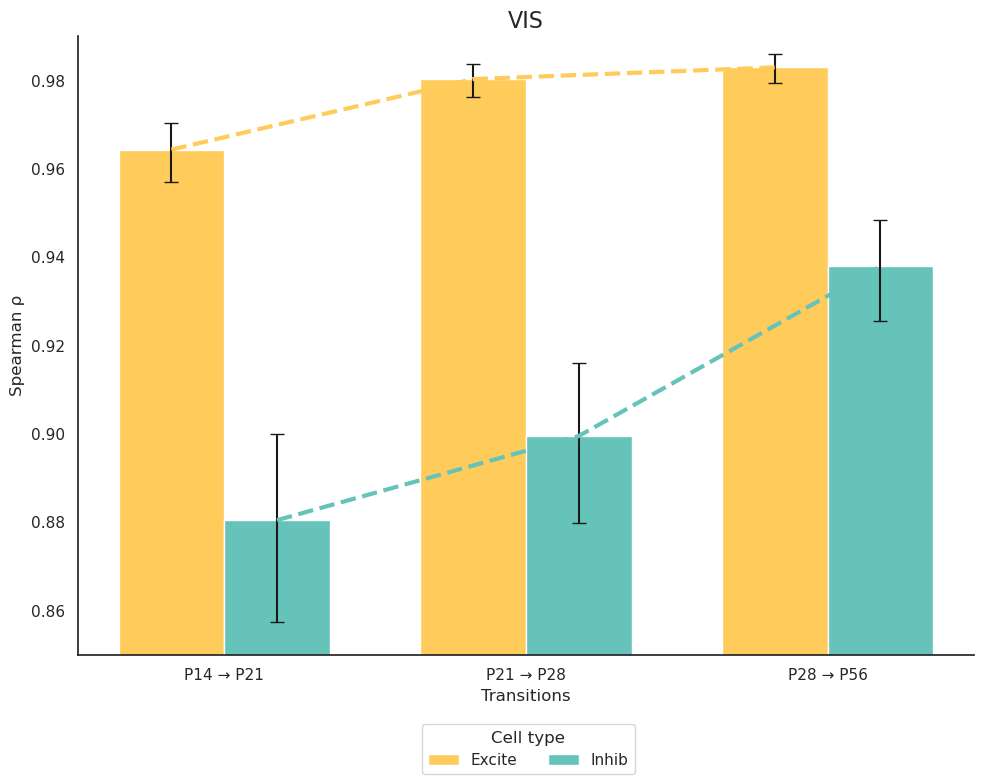

In [15]:
# Figure 4c: transition correlations, VisCortex only
vis_plot = cor_neurons_df[cor_neurons_df["Region"]=="VisCortex"]

# Order by Transition
transitions = list(vis_plot["Transition"].unique())

plt.figure(figsize=(10,8))
ax = plt.gca()

# x positions for transitions
x = np.arange(len(transitions))
width = 0.35   # width of each bar

# Plot each cell type separately
for i, ct in enumerate(cts):
    ct_df = vis_plot[vis_plot["Cell type"] == ct].sort_values("Transition")

    # x positions offset for each group
    xs = x - width/2 if ct == "Excite" else x + width/2

    # means
    ys = ct_df["Estimate"].values

    # asymmetric error bars
    yerr = np.vstack([
        ys - ct_df["LCI"].values,
        ct_df["UCI"].values - ys
    ])

    # draw bars
    ax.bar(
        xs, ys, width,
        yerr=yerr,
        label=ct,
        capsize=5,
        color=cts_palette[ct]
    )

    # store x positions for trend lines
    ct_df["xpos"] = xs

    # trend line
    ax.plot(xs, ys, color=cts_palette[ct], linestyle="--", linewidth=3.0)

ax.set_xticks(x)
ax.set_xticklabels(transitions)
ax.set_ylim(0.85, 0.99)
ax.set_ylabel("Spearman ρ")
ax.set_xlabel("Transitions")
ax.set_title("VIS", fontsize=16)

sns.despine()
plt.legend(title="Cell type", bbox_to_anchor=(0.63, -0.1), ncol=2)
plt.tight_layout()
plt.savefig("../plots/VIS.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
vis_plot

,Estimate,LCI,UCI,Region,Cell type,Transition
6,0.964306,0.957020,0.970376,VisCortex,Excite,P14 → P21
7,0.880438,0.857275,0.900044,VisCortex,Inhib,P14 → P21
8,0.980269,0.976202,0.983647,VisCortex,Excite,P21 → P28
9,0.899474,0.879763,0.916098,VisCortex,Inhib,P21 → P28
10,0.982918,0.979392,0.985846,VisCortex,Excite,P28 → P56
11,0.937927,0.925460,0.948364,VisCortex,Inhib,P28 → P56


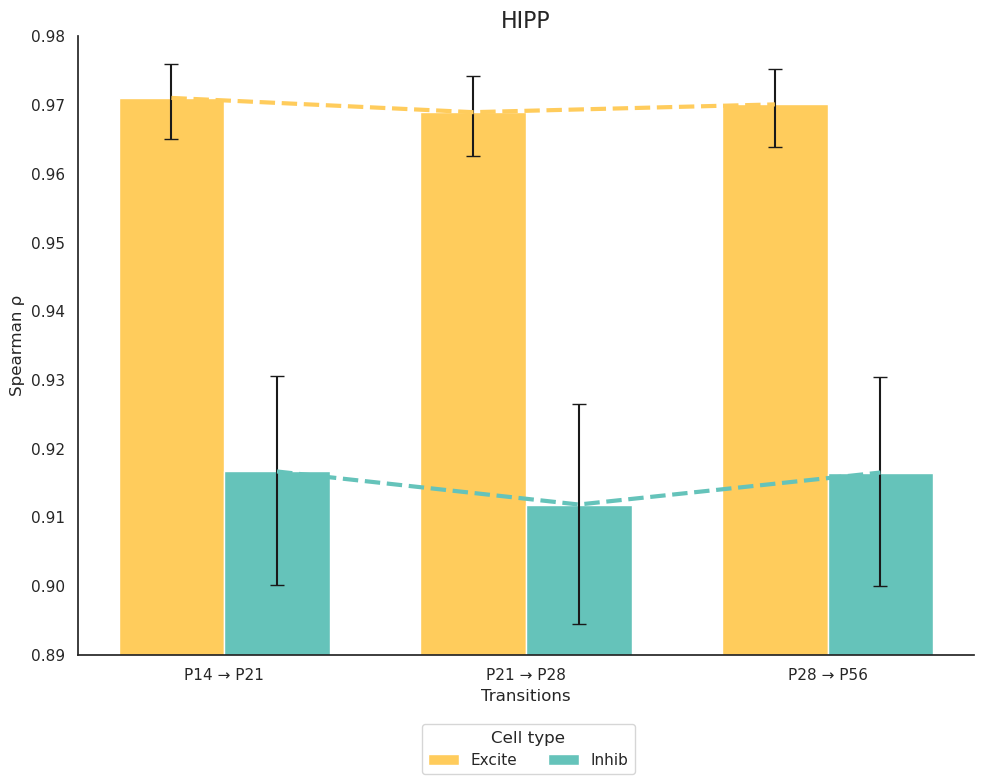

In [17]:
# transition correlations, Hippocampus only
hipp_plot = cor_neurons_df[cor_neurons_df["Region"]=="Hippocampus"]

# Order by Transition
transitions = list(hipp_plot["Transition"].unique())

plt.figure(figsize=(10,8))
ax = plt.gca()

# x positions for transitions
x = np.arange(len(transitions))
width = 0.35   # width of each bar

# Plot each cell type separately
for i, ct in enumerate(cts):
    ct_df = hipp_plot[hipp_plot["Cell type"] == ct].sort_values("Transition")

    # x positions offset for each group
    xs = x - width/2 if ct == "Excite" else x + width/2

    # means
    ys = ct_df["Estimate"].values

    # asymmetric error bars
    yerr = np.vstack([
        ys - ct_df["LCI"].values,
        ct_df["UCI"].values - ys
    ])

    # draw bars
    ax.bar(
        xs, ys, width,
        yerr=yerr,
        label=ct,
        capsize=5,
        color=cts_palette[ct]
    )

    # store x positions for trend lines
    ct_df["xpos"] = xs

    # trend line
    ax.plot(xs, ys, color=cts_palette[ct], linestyle="--", linewidth=3.0)

ax.set_xticks(x)
ax.set_xticklabels(transitions)
ax.set_ylim(0.89, 0.98)
ax.set_ylabel("Spearman ρ")
ax.set_xlabel("Transitions")
ax.set_title("HIPP", fontsize=16)

sns.despine()
plt.legend(title="Cell type", bbox_to_anchor=(0.63, -0.1), ncol=2)
plt.tight_layout()
plt.savefig("../plots/HIPP.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
hipp_plot

,Estimate,LCI,UCI,Region,Cell type,Transition
0,0.971003,0.965060,0.975948,Hippocampus,Excite,P14 → P21
1,0.916648,0.900128,0.930536,Hippocampus,Inhib,P14 → P21
2,0.968928,0.962567,0.974222,Hippocampus,Excite,P21 → P28
3,0.911842,0.894421,0.926499,Hippocampus,Inhib,P21 → P28
4,0.970060,0.963926,0.975163,Hippocampus,Excite,P28 → P56
5,0.916498,0.899949,0.930409,Hippocampus,Inhib,P28 → P56


## 6. Compute Correlations of Exon Inclusion for Each Cell Type Between the Visual Cortex and the Hippocampus

- Order the correlations by timepoints in the developmental process
- Compute the lower bound and upper bound of the error bars indicating 95% confidence intervals for Spearmans's correlation for both neuronal cell types
- Create a dataframe containing correlation values between visual cortex and hippocampus, lower bound and upper bound of 95% confidence intervals, timepoints in the development process, and cell type for the cross-region correlations
- Create bar charts showing the changes in correlation values at each timepoint between the visual cortex and hippocampus. The error bar indicating the upper and lower bound of the data points.  

In [19]:
cor_neu_reg = []

for tp in timepoints:
    for ct in cts:
        col1 = [col for col in type_neurons.columns if tp in col and "Hippocampus" in col and ct in col]
        col2 = [col for col in type_neurons.columns if tp in col and "VisCortex" in col and ct in col]
        if len(col1) == 0 or len(col2) == 0:
            continue
        v1 = type_neurons[col1].mean(axis=1)
        v2 = type_neurons[col2].mean(axis=1)
        r, lci, uci = compute_spearman_ci(v1, v2)
        cor_neu_reg.append({
            "Estimate": r,
            "LCI": lci,
            "UCI": uci,
            "Timepoint": tp,
            "Cell type": ct
        })

cor_neu_reg_df = pd.DataFrame(cor_neu_reg)
cor_neu_reg_df

,Estimate,LCI,UCI,Timepoint,Cell type
0,0.962237,0.954538,0.968653,P14,Excite
1,0.910373,0.892679,0.925265,P14,Inhib
2,0.973686,0.968284,0.978179,P21,Excite
3,0.904615,0.885851,0.920424,P21,Inhib
4,0.966287,0.959397,0.972025,P28,Excite
5,0.891848,0.870743,0.909672,P28,Inhib
6,0.957619,0.949003,0.964806,P56,Excite
7,0.944796,0.933661,0.954106,P56,Inhib


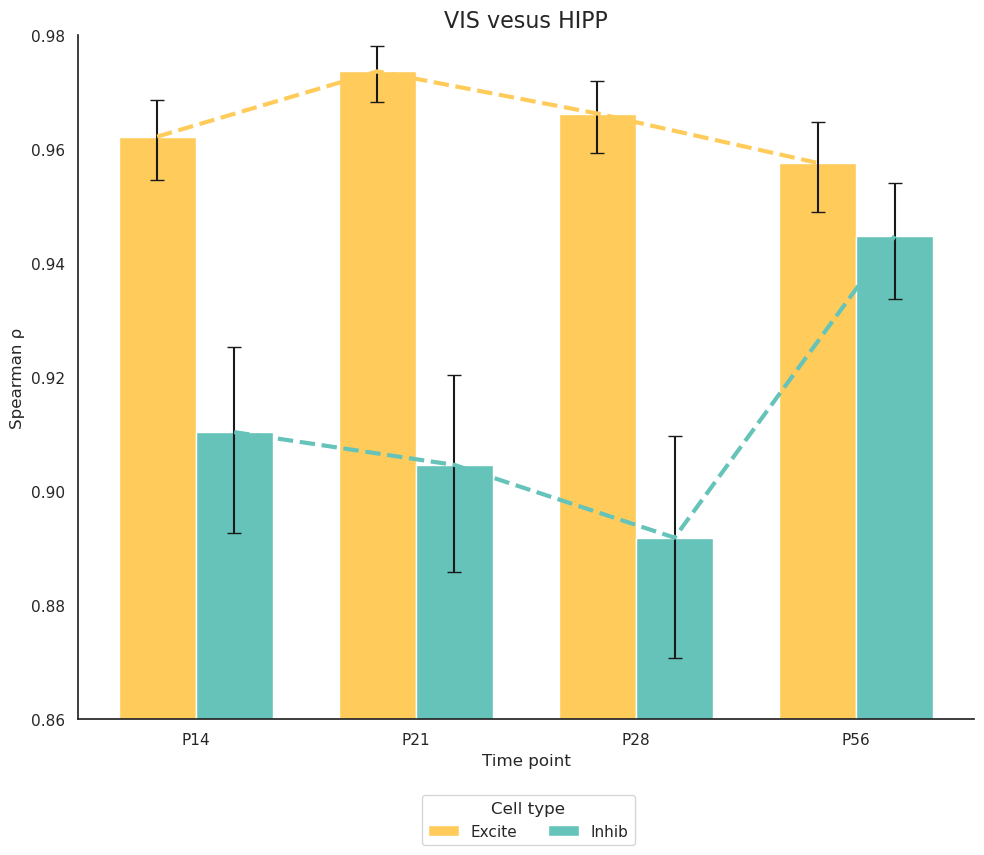

In [20]:
plt.figure(figsize=(10,8))
ax = plt.gca()

# Order by Timepoint
cor_neu_reg_df["Timepoint"] = pd.Categorical(
    cor_neu_reg_df["Timepoint"],
    categories=timepoints,
    ordered=True
)

# Positions for Timepoints
x = np.arange(len(timepoints))
width = 0.35 

# Plot each cell type separately 
for ct in cts:
    ct_df = cor_neu_reg_df[cor_neu_reg_df["Cell type"] == ct].sort_values("Timepoint")

    # offset each group 
    xs = x - width/2 if ct == "Excite" else x + width/2

    ys = ct_df["Estimate"].values

    # Error bars
    yerr = np.vstack([
        np.maximum(0, ys - ct_df["LCI"].values),
        np.maximum(0, ct_df["UCI"].values - ys)
    ])

    # bar plot with correct yerr
    ax.bar(
        xs,
        ys,
        width,
        yerr=yerr,
        capsize=5,
        color=cts_palette[ct],
        label=ct
    )

    # store x positions for trend lines
    ct_df["xpos"] = xs

    # trend line
    ax.plot(xs, ys, color=cts_palette[ct], linestyle="--", linewidth=3.0)

ax.set_ylim(0.86, 0.98)
ax.set_ylabel("Spearman ρ")
ax.set_xticks(x)
ax.set_xticklabels(timepoints)
ax.set_xlabel("Time point")
ax.set_title("VIS vesus HIPP", fontsize=16)

sns.despine()
plt.legend(title="Cell type", bbox_to_anchor=(0.63, -0.1), ncol=2)
plt.tight_layout()
plt.savefig("../plots/VISversusHIPP.png", dpi=300, bbox_inches="tight")
plt.show()
